[*] Loading Genomic Matrix...
[+] Loaded Matrix Shape: 780 patients, 8401 genes.
[*] Standardizing gene expressions (mean=0, variance=1)...
[*] Running Principal Component Analysis...

[+] SUCCESS! Compressed 8,401 genes down to 501 Principal Components.
[+] We kept 95% of the biological variance while dropping 7900 columns of noise!


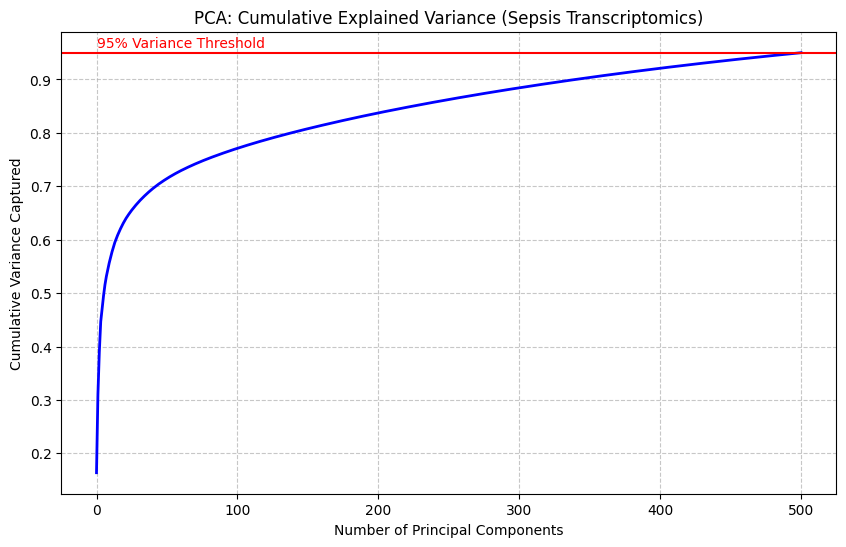


[+] Saved reduced matrix to: /workspace/data/processed/geo_pool/X_matrix_pca_reduced.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os

# 1. Define your exact Docker file paths
data_dir = "/workspace/data/processed/geo_pool"
X_path = os.path.join(data_dir, "X_matrix_labeled.csv")
y_path = os.path.join(data_dir, "y_labels.csv")

print("[*] Loading Genomic Matrix...")
X = pd.read_csv(X_path, index_col=0) 
y = pd.read_csv(y_path, index_col=0)

# Add this single line right here to flip the matrix!
X = X.T 

print(f"[+] Loaded Matrix Shape: {X.shape[0]} patients, {X.shape[1]} genes.")

# 2. Standardization (CRITICAL STEP)
# Some genes naturally express at 10,000 units, others at 5 units. 
# PCA will unfairly favor the "loud" genes if we don't put them all on the same scale.
print("[*] Standardizing gene expressions (mean=0, variance=1)...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Fit PCA to find out how much variance we can compress
print("[*] Running Principal Component Analysis...")
# We will initially ask PCA to calculate enough components to keep 95% of the original information
pca = PCA(n_components=0.95, random_state=42) 
X_pca = pca.fit_transform(X_scaled)

# 4. Check our results
n_components_kept = pca.n_components_
print(f"\n[+] SUCCESS! Compressed 8,401 genes down to {n_components_kept} Principal Components.")
print(f"[+] We kept 95% of the biological variance while dropping {8401 - n_components_kept} columns of noise!")

# 5. Visualize the "Elbow Curve" (Cumulative Explained Variance)
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), color='b', linewidth=2)
plt.title('PCA: Cumulative Explained Variance (Sepsis Transcriptomics)')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Captured')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0, 0.96, '95% Variance Threshold', color = 'red')
plt.show()

# 6. Save the new, lightweight matrix for Model Training
output_path = os.path.join(data_dir, "X_matrix_pca_reduced.csv")
# Create a new dataframe with our PC columns (PC1, PC2, PC3...)
pc_columns = [f"PC{i+1}" for i in range(n_components_kept)]
X_pca_df = pd.DataFrame(X_pca, index=X.index, columns=pc_columns)
X_pca_df.to_csv(output_path)
print(f"\n[+] Saved reduced matrix to: {output_path}")